# Experiment 7 -- Qubit and depth ablation on the 10-class / 2500-per-class regime

Every ablation so far (`configs/ablation/`, Experiment 3) ran on the reduced **3-class subset** --
digits 0/1/2, 300 train + 100 test per class. Every configuration landed in a **97.7%-99.7%** band with
no clear trend against either qubit count or depth, and the later gradient-variance diagnostic confirmed
that accuracy does not track gradient health there: Pearson $r = +0.12$ across the qubit sweep *despite*
a 15-fold drop in gradient variance. The natural reading is a **ceiling effect** -- the task is too easy,
and a 300-image test set too coarse-grained, for real architectural differences to surface.

Experiment 1's 10-class full-dataset comparison did show a real, much larger gap (98.67% classical vs.
97.07% hybrid, 1.6pp), but **no qubit/depth ablation was ever run there**: `hybrid_full` costs ~304s/epoch
and the full matrix was not tractable.

This notebook covers the middle ground:

| | 3-class subset (Exp. 3) | **full10_2500 (this run)** | full dataset (Exp. 1) |
|---|---|---|---|
| Classes | 0, 1, 2 | **all 10** | all 10 |
| Train | 900 (300/class) | **25,000 (2500/class)** | 60,000 |
| Test | 300 (100/class) | **5,000 (500/class)** | 10,000 |
| Batch size | 32 | **64** | 64 |
| Epochs | 15 | **15** | 12 |
| Ablated? | yes | **yes** | no -- not tractable |

All 10 classes gives genuine decision-boundary complexity; capping at 2500/500 per class keeps per-epoch
cost far below `hybrid_full`'s. The test set is **16.7x larger** than the subset's, so the smallest
resolvable accuracy difference drops from 0.33pp to 0.02pp -- if Experiment 3's zigzag was test-set
quantisation noise, it should shrink here.

## Design

Both sweeps use the **identical OFAT grid** as Experiment 3, so the only thing that changes is the
dataset regime:

- **Sweep A (qubit count)**: `n_qubits` in {2, 4, 6, 8}, `n_qlayers` fixed at 2.
- **Sweep B (circuit depth)**: `n_qlayers` in {1, 2, 3, 4}, `n_qubits` fixed at 4.

`qubits_4` and `depth_2` describe the same configuration (4 qubits, 2 layers). Sweep A trains it; Sweep B
copies it, following the reuse convention already used in Experiments 3-5. That makes **7 unique trained
configurations**, not 8.

`data_seed` stays at **42**, matching every other experiment in the project, so this regime's data
selection is reproducible and comparable. `training_seed` is also 42 -- this is a single-seed run, exactly
as Experiment 3 was before Phase 4 added the multi-seed follow-up.

### Hyperparameter choices (stated explicitly so they are citable)

- **batch_size 64** -- matches `configs/base/hybrid_full.yaml`; this regime is closer in scale to the full
  dataset than to the 3-class subset (which used 32).
- **epochs 15** -- three more than `hybrid_full`'s 12, since Section 4.4 flagged a possible non-convergence
  caveat for the full run at 12. This regime is 2.4x smaller so should converge sooner, but the headroom
  is cheap.
- **learning_rate 0.001, Adam** -- identical to every other experiment.
- **device `default.qubit`** -- matches `configs/ablation/`, *not* `hybrid_full`'s `lightning.qubit`.
  Measured on this machine, `lightning.qubit` is ~6x **slower** at 2-8 qubits: its per-call C++ dispatch
  overhead dominates until roughly 15 qubits, and this ablation never leaves that range. Keeping
  `default.qubit` also makes the comparison against Experiment 3 a pure dataset-regime change.

**Reproduce with:**
```bash
python -m src.experiments.run_ablation --sweep qubits --dataset-regime full10_2500
python -m src.experiments.run_ablation --sweep depth  --dataset-regime full10_2500
```

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import yaml
from IPython.display import Image, display

project_root = Path.cwd().resolve()
if not (project_root / 'results').exists():
    project_root = Path('d:/Dissertation/qcnn-dissertation').resolve()

sys.path.insert(0, str(project_root))

from src.data.dataset import get_dataloaders
from src.models.hybrid_cnn import HybridCNN
from src.training.engine import evaluate
from src.training.metrics import confusion_matrix_fig

print('Imports OK')
print(f'Project root: {project_root}')

Imports OK
Project root: D:\Dissertation\qcnn-dissertation


## Configuration

Points at `configs/ablation_full10/*.yaml` and the results written by
`run_ablation.py --dataset-regime full10_2500` under `results/ablation_full10/`.
Experiment 3's paths are loaded alongside for the side-by-side in section 5.

In [2]:
def load_config(config_path):
    with open(config_path, 'r', encoding='utf-8') as f:
        config = yaml.safe_load(f)
    config['dataset']['data_root'] = str(project_root / 'data')
    return config

QUBIT_POINTS = [2, 4, 6, 8]
DEPTH_POINTS = [1, 2, 3, 4]

SWEEP_A_RUNS = [
    {'label': f'qubits_{n}', 'reused': False,
     'config': project_root / 'configs' / 'ablation_full10' / f'qubits_{n}.yaml',
     'results_dir': project_root / 'results' / 'ablation_full10' / f'qubits_{n}'}
    for n in QUBIT_POINTS
]
SWEEP_B_RUNS = [
    {'label': f'depth_{n}', 'reused': n == 2,
     'config': project_root / 'configs' / 'ablation_full10' / f'depth_{n}.yaml',
     'results_dir': project_root / 'results' / 'ablation_full10' / f'depth_{n}'}
    for n in DEPTH_POINTS
]

SUMMARY_CSV = project_root / 'results' / 'ablation_full10' / 'metrics_summary.csv'
EXP3_SUMMARY_CSV = project_root / 'results' / 'ablation' / 'metrics_summary.csv'

rows = []
for spec in SWEEP_A_RUNS + SWEEP_B_RUNS:
    if not spec['config'].exists():
        continue
    cfg = load_config(spec['config'])
    ds, tr = cfg['dataset'], cfg['training']
    rows.append({
        'run': spec['label'],
        'n_qubits': cfg['model']['n_qubits'],
        'n_qlayers': cfg['model']['n_qlayers'],
        'num_classes': cfg['model']['num_classes'],
        'train_per_class': ds['samples_per_class_train'],
        'test_per_class': ds['samples_per_class_test'],
        'batch_size': tr['batch_size'],
        'epochs': tr['epochs'],
        'lr': tr['learning_rate'],
        'device': cfg['model']['device'],
        'data_seed': cfg['data_seed'],
        'training_seed': cfg['training_seed'],
        'reused': spec['reused'],
    })

config_summary_df = pd.DataFrame(rows)
display(config_summary_df)

assert (config_summary_df['data_seed'] == 42).all(), 'data_seed must stay 42 everywhere'
n_classes = config_summary_df['num_classes'].iloc[0]
print(f"\nTotal train = {config_summary_df['train_per_class'].iloc[0] * n_classes:,}"
      f" | test = {config_summary_df['test_per_class'].iloc[0] * n_classes:,}")
print(f"Unique trained configurations: {(~config_summary_df['reused']).sum()} of {len(config_summary_df)}")

,run,n_qubits,n_qlayers,num_classes,train_per_class,test_per_class,batch_size,epochs,lr,device,data_seed,training_seed,reused
0,qubits_2,2,2,10,2500,500,64,15,0.001,default.qubit,42,42,False
1,qubits_4,4,2,10,2500,500,64,15,0.001,default.qubit,42,42,False
2,qubits_6,6,2,10,2500,500,64,15,0.001,default.qubit,42,42,False
3,qubits_8,8,2,10,2500,500,64,15,0.001,default.qubit,42,42,False
4,depth_1,4,1,10,2500,500,64,15,0.001,default.qubit,42,42,False
5,depth_2,4,2,10,2500,500,64,15,0.001,default.qubit,42,42,True
6,depth_3,4,3,10,2500,500,64,15,0.001,default.qubit,42,42,False
7,depth_4,4,4,10,2500,500,64,15,0.001,default.qubit,42,42,False



Total train = 25,000 | test = 5,000
Unique trained configurations: 7 of 8


## 1. Dataset regime check

Confirms `subsample_per_class` produced exactly the intended cap for all 10 classes. The caps are well
inside MNIST's natural class sizes -- the smallest train class is 5,421 (digit 5) against a 2,500 cap, and
the smallest test class is 892 (also digit 5) against a 500 cap -- so no class is silently short.

In [3]:
import collections

cfg = load_config(SWEEP_A_RUNS[0]['config'])
train_loader, test_loader = get_dataloaders(cfg)

train_counts = collections.Counter()
for _, y in train_loader:
    train_counts.update(y.tolist())
test_counts = collections.Counter()
for _, y in test_loader:
    test_counts.update(y.tolist())

balance_df = pd.DataFrame({
    'train': pd.Series(dict(sorted(train_counts.items()))),
    'test': pd.Series(dict(sorted(test_counts.items()))),
})
balance_df.index.name = 'digit'
display(balance_df)
print(f'totals: train={sum(train_counts.values()):,}  test={sum(test_counts.values()):,}')
print(f'perfectly balanced: {balance_df["train"].nunique() == 1 and balance_df["test"].nunique() == 1}')

,train,test
digit,,
0,2500,500
1,2500,500
2,2500,500
3,2500,500
4,2500,500
5,2500,500
6,2500,500
7,2500,500
8,2500,500


totals: train=25,000  test=5,000
perfectly balanced: True


## 2. Sweep A -- qubit count

`n_qlayers` fixed at 2. Final-epoch metrics per `n_qubits`, plus the accuracy / parameter-count figure.

,sweep,n_qubits,n_qlayers,accuracy,f1_macro,precision_macro,recall_macro,parameter_count,epoch_time_sec,training_seed,data_seed,output_dir
4,qubits,2,2,0.6022,0.567560,0.576976,0.6022,1796.0,8.543738,42.0,42.0,results/ablation_full10/qubits_2
5,qubits,4,2,0.9534,0.953482,0.954156,0.9534,2334.0,10.591253,42.0,42.0,results/ablation_full10/qubits_4
6,qubits,6,2,0.9566,0.956702,0.957433,0.9566,2872.0,15.796459,42.0,42.0,results/ablation_full10/qubits_6
7,qubits,8,2,0.9618,0.961900,0.962449,0.9618,3410.0,20.836955,42.0,42.0,results/ablation_full10/qubits_8


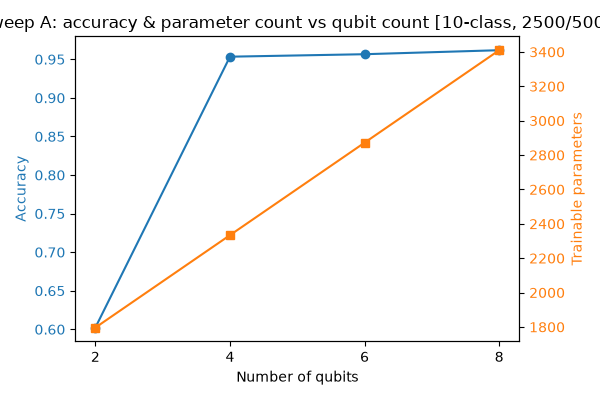

In [4]:
summary_df = pd.read_csv(SUMMARY_CSV) if SUMMARY_CSV.exists() else pd.DataFrame()

if not summary_df.empty:
    sweep_a_df = summary_df[summary_df['sweep'] == 'qubits'].sort_values('n_qubits')
    display(sweep_a_df)
    fig_path = project_root / 'figures' / 'ablation_full10_qubits.png'
    if fig_path.exists():
        display(Image(filename=str(fig_path)))
else:
    sweep_a_df = pd.DataFrame()
    print('No results yet -- run:\n'
          '  python -m src.experiments.run_ablation --sweep qubits --dataset-regime full10_2500')

## 3. Sweep B -- circuit depth

`n_qubits` fixed at 4. `depth_2` is the copied `qubits_4` run, not a retrain -- see
`results/ablation_full10/depth_2/REUSED_FROM.txt`.

,sweep,n_qubits,n_qlayers,accuracy,f1_macro,precision_macro,recall_macro,parameter_count,epoch_time_sec,training_seed,data_seed,output_dir
0,depth,4,1,0.8282,0.814270,0.846604,0.8282,2330.0,9.885111,42.0,42.0,results/ablation_full10/depth_1
1,depth,4,2,0.9534,0.953482,0.954156,0.9534,2334.0,10.591253,42.0,42.0,results/ablation_full10/depth_2
2,depth,4,3,0.9492,0.949280,0.949730,0.9492,2338.0,12.378350,42.0,42.0,results/ablation_full10/depth_3
3,depth,4,4,0.9576,0.957571,0.957859,0.9576,2342.0,13.651467,42.0,42.0,results/ablation_full10/depth_4


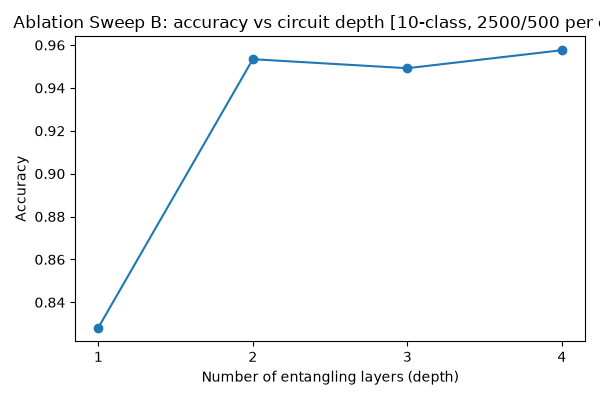

depth_2 reused from: results/ablation_full10/qubits_4


In [5]:
if not summary_df.empty:
    sweep_b_df = summary_df[summary_df['sweep'] == 'depth'].sort_values('n_qlayers')
    display(sweep_b_df)
    fig_path = project_root / 'figures' / 'ablation_full10_depth.png'
    if fig_path.exists():
        display(Image(filename=str(fig_path)))
else:
    sweep_b_df = pd.DataFrame()
    print('No results yet -- run:\n'
          '  python -m src.experiments.run_ablation --sweep depth --dataset-regime full10_2500')

reused_marker = project_root / 'results' / 'ablation_full10' / 'depth_2' / 'REUSED_FROM.txt'
if reused_marker.exists():
    print(f'depth_2 reused from: {reused_marker.read_text().strip()}')

## 4. The 7 unique configurations

One row per *trained* configuration -- the shared 4-qubit/2-layer point counted once, not twice.

In [6]:
unique_df = (summary_df
             .drop_duplicates(subset=['n_qubits', 'n_qlayers'])
             .sort_values(['n_qubits', 'n_qlayers'])
             [['n_qubits', 'n_qlayers', 'accuracy', 'f1_macro', 'precision_macro',
               'recall_macro', 'parameter_count', 'epoch_time_sec']]
             .reset_index(drop=True))
display(unique_df)

print(f'unique configurations: {len(unique_df)}')
print(f'accuracy range : {unique_df["accuracy"].min():.4f} - {unique_df["accuracy"].max():.4f} '
      f'(spread {100 * (unique_df["accuracy"].max() - unique_df["accuracy"].min()):.2f} pp)')
print(f'f1_macro range : {unique_df["f1_macro"].min():.4f} - {unique_df["f1_macro"].max():.4f}')
print(f'epoch time     : {unique_df["epoch_time_sec"].min():.1f}s - {unique_df["epoch_time_sec"].max():.1f}s')

,n_qubits,n_qlayers,accuracy,f1_macro,precision_macro,recall_macro,parameter_count,epoch_time_sec
0,2,2,0.6022,0.567560,0.576976,0.6022,1796.0,8.543738
1,4,1,0.8282,0.814270,0.846604,0.8282,2330.0,9.885111
2,4,2,0.9534,0.953482,0.954156,0.9534,2334.0,10.591253
3,4,3,0.9492,0.949280,0.949730,0.9492,2338.0,12.378350
4,4,4,0.9576,0.957571,0.957859,0.9576,2342.0,13.651467
5,6,2,0.9566,0.956702,0.957433,0.9566,2872.0,15.796459
6,8,2,0.9618,0.961900,0.962449,0.9618,3410.0,20.836955


unique configurations: 7
accuracy range : 0.6022 - 0.9618 (spread 35.96 pp)
f1_macro range : 0.5676 - 0.9619
epoch time     : 8.5s - 20.8s


## 5. Side-by-side against Experiment 3's 3-class subset

The headline question: **does the wider-headroom, finer-grained regime produce a bigger spread and a
cleaner trend, or does the zigzag persist?**

A persistent zigzag across two very different datasets is strong evidence the effect is genuinely noise
rather than an architectural signal masked by the subset's ceiling.

In [7]:
exp3_df = pd.read_csv(EXP3_SUMMARY_CSV)

def unique_points(df, regime):
    out = (df.drop_duplicates(subset=['n_qubits', 'n_qlayers'])
             .sort_values(['n_qubits', 'n_qlayers'])
             [['n_qubits', 'n_qlayers', 'accuracy', 'f1_macro', 'epoch_time_sec']]
             .reset_index(drop=True))
    out['regime'] = regime
    return out

exp3_u = unique_points(exp3_df, 'subset3')
exp7_u = unique_points(summary_df, 'full10_2500')

side = exp3_u.merge(exp7_u, on=['n_qubits', 'n_qlayers'], suffixes=('_subset3', '_full10'))
side['acc_delta_pp'] = 100 * (side['accuracy_full10'] - side['accuracy_subset3'])
display(side[['n_qubits', 'n_qlayers', 'accuracy_subset3', 'accuracy_full10', 'acc_delta_pp',
              'f1_macro_subset3', 'f1_macro_full10',
              'epoch_time_sec_subset3', 'epoch_time_sec_full10']])

,n_qubits,n_qlayers,accuracy_subset3,accuracy_full10,acc_delta_pp,f1_macro_subset3,f1_macro_full10,epoch_time_sec_subset3,epoch_time_sec_full10
0,2,2,0.993333,0.6022,-39.113333,0.993333,0.567560,0.603161,8.543738
1,4,1,0.993333,0.8282,-16.513333,0.993333,0.814270,0.601542,9.885111
2,4,2,0.976667,0.9534,-2.326667,0.976814,0.953482,0.715185,10.591253
3,4,3,0.986667,0.9492,-3.746667,0.986665,0.949280,0.802377,12.378350
4,4,4,0.990000,0.9576,-3.240000,0.990000,0.957571,0.856793,13.651467
5,6,2,0.996667,0.9566,-4.006667,0.996667,0.956702,1.202888,15.796459
6,8,2,0.980000,0.9618,-1.820000,0.979982,0.961900,1.434543,20.836955


In [8]:
def spread_stats(df, label, n_test):
    acc = df['accuracy']
    return {
        'regime': label,
        'test_images': n_test,
        'resolution_pp': 100 / n_test,
        'min_acc': acc.min(), 'max_acc': acc.max(),
        'spread_pp': 100 * (acc.max() - acc.min()),
        'std_pp': 100 * acc.std(),
        'spread_in_resolution_units': (acc.max() - acc.min()) / (1 / n_test),
    }

spread_df = pd.DataFrame([
    spread_stats(exp3_u, 'subset3 (3-class)', 300),
    spread_stats(exp7_u, 'full10_2500 (10-class)', 5000),
])
display(spread_df)

print('`resolution_pp` is the smallest accuracy difference the test set can express (one image).')
print('`spread_in_resolution_units` is the observed spread measured in those units -- i.e. how many')
print('single-image steps separate the best and worst configuration. If the subset spread was mostly')
print('test-set quantisation, this number should be small there and larger here.')

,regime,test_images,resolution_pp,min_acc,max_acc,spread_pp,std_pp,spread_in_resolution_units
0,subset3 (3-class),300,0.333333,0.976667,0.996667,2.00,0.741798,6.0
1,full10_2500 (10-class),5000,0.020000,0.602200,0.961800,35.96,13.433158,1798.0


`resolution_pp` is the smallest accuracy difference the test set can express (one image).
`spread_in_resolution_units` is the observed spread measured in those units -- i.e. how many
single-image steps separate the best and worst configuration. If the subset spread was mostly
test-set quantisation, this number should be small there and larger here.


## 6. Monotonicity check

Is either sweep monotonic now? Reported as Spearman rank correlation (does accuracy rise with the swept
quantity at all?) plus a count of sign changes in the successive differences (how much zigzag is left).

In [9]:
def trend_report(df, x_column, label):
    df = df.sort_values(x_column)
    acc = df['accuracy'].values
    diffs = np.diff(acc)
    signs = np.sign(diffs)
    sign_changes = int((signs[:-1] * signs[1:] < 0).sum()) if len(signs) > 1 else 0
    spearman = pd.Series(acc).corr(pd.Series(df[x_column].values), method='spearman')
    return {
        'sweep': label,
        'spearman_rho': spearman,
        'monotonic': bool((signs > 0).all() or (signs < 0).all()),
        'sign_changes': sign_changes,
        'peak_at': df[x_column].values[int(np.argmax(acc))],
        'spread_pp': 100 * (acc.max() - acc.min()),
    }

trend_rows = []
for regime_label, sdf in [('subset3', exp3_df), ('full10_2500', summary_df)]:
    for sweep, x_column in [('qubits', 'n_qubits'), ('depth', 'n_qlayers')]:
        sub = sdf[sdf['sweep'] == sweep]
        if not sub.empty:
            trend_rows.append({'regime': regime_label, **trend_report(sub, x_column, sweep)})

trend_df = pd.DataFrame(trend_rows)
display(trend_df)

print('monotonic=True means accuracy moved in one direction across the whole sweep.')
print('sign_changes counts direction reversals: 0 = clean, 2 = full zigzag on a 4-point sweep.')

,regime,sweep,spearman_rho,monotonic,sign_changes,peak_at,spread_pp
0,subset3,qubits,0.0,False,2,6,2.000000
1,subset3,depth,-0.2,False,1,1,1.666667
2,full10_2500,qubits,1.0,True,0,8,35.960000
3,full10_2500,depth,0.8,False,2,4,12.940000


monotonic=True means accuracy moved in one direction across the whole sweep.
sign_changes counts direction reversals: 0 = clean, 2 = full zigzag on a 4-point sweep.


## 7. Training curves and convergence

15 epochs was chosen with Section 4.4's non-convergence caveat in mind. These curves show whether that
headroom was enough -- a still-falling test loss at epoch 15 would mean the comparison is between
under-trained models rather than converged ones.

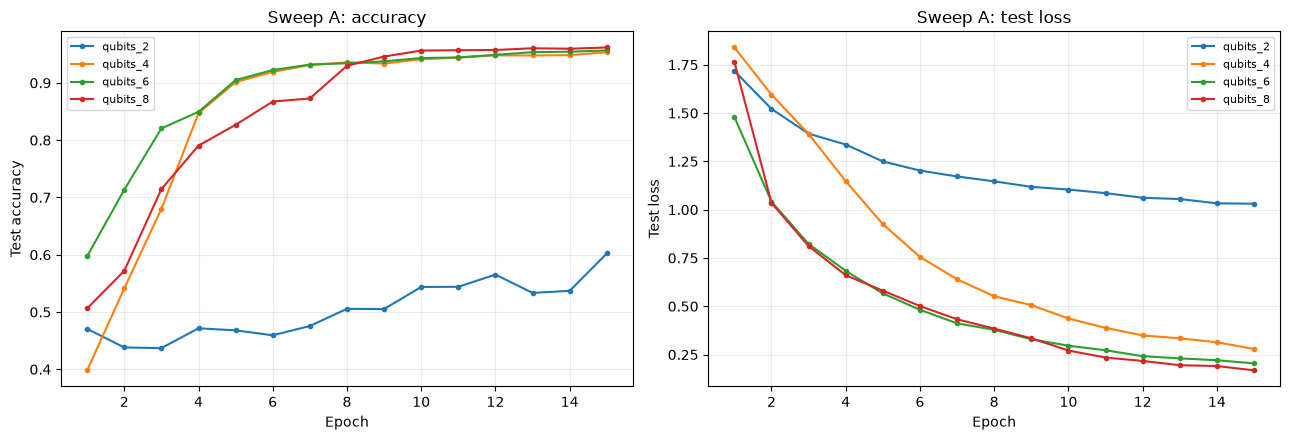

Final-epoch test-loss change (epoch 15 minus epoch 14) -- near zero means converged:
  qubits_2   test_loss 1.0309  delta -0.0020
  qubits_4   test_loss 0.2787  delta -0.0351
  qubits_6   test_loss 0.2044  delta -0.0163
  qubits_8   test_loss 0.1683  delta -0.0224
  depth_1    test_loss 0.5384  delta -0.0213
  depth_2    test_loss 0.2787  delta -0.0351
  depth_3    test_loss 0.2346  delta -0.0121
  depth_4    test_loss 0.1759  delta +0.0020


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for spec in SWEEP_A_RUNS:
    csv = spec['results_dir'] / 'metrics.csv'
    if csv.exists():
        d = pd.read_csv(csv)
        axes[0].plot(d['epoch'], d['accuracy'], marker='o', ms=3, label=spec['label'])
        axes[1].plot(d['epoch'], d['test_loss'], marker='o', ms=3, label=spec['label'])
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Test accuracy'); axes[0].set_title('Sweep A: accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test loss'); axes[1].set_title('Sweep A: test loss')
for a in axes:
    a.legend(fontsize=8); a.grid(alpha=0.25)
fig.tight_layout()
plt.show()

print('Final-epoch test-loss change (epoch 15 minus epoch 14) -- near zero means converged:')
for spec in SWEEP_A_RUNS + SWEEP_B_RUNS:
    csv = spec['results_dir'] / 'metrics.csv'
    if csv.exists():
        d = pd.read_csv(csv)
        delta = d['test_loss'].iloc[-1] - d['test_loss'].iloc[-2]
        print(f"  {spec['label']:<10} test_loss {d['test_loss'].iloc[-1]:.4f}  delta {delta:+.4f}")

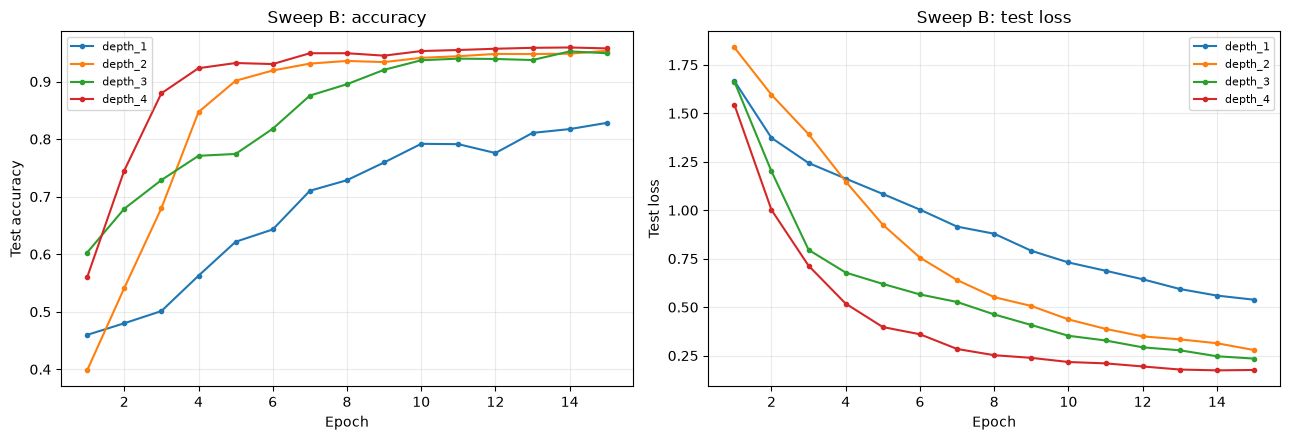

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for spec in SWEEP_B_RUNS:
    csv = spec['results_dir'] / 'metrics.csv'
    if csv.exists():
        d = pd.read_csv(csv)
        axes[0].plot(d['epoch'], d['accuracy'], marker='o', ms=3, label=spec['label'])
        axes[1].plot(d['epoch'], d['test_loss'], marker='o', ms=3, label=spec['label'])
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Test accuracy'); axes[0].set_title('Sweep B: accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test loss'); axes[1].set_title('Sweep B: test loss')
for a in axes:
    a.legend(fontsize=8); a.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 8. Wall-clock cost

The measured cost, so future scaling decisions can be planned against real numbers rather than the
estimate used to size this run.

In [12]:
timing_rows = []
for spec in SWEEP_A_RUNS + SWEEP_B_RUNS:
    csv = spec['results_dir'] / 'metrics.csv'
    if not csv.exists() or spec['reused']:
        continue
    d = pd.read_csv(csv)
    timing_rows.append({
        'run': spec['label'],
        'mean_epoch_sec': d['epoch_time_sec'].mean(),
        'total_sec': d['epoch_time_sec'].sum(),
        'total_min': d['epoch_time_sec'].sum() / 60,
    })

timing_df = pd.DataFrame(timing_rows).sort_values('mean_epoch_sec')
display(timing_df)
print(f"Total wall-clock across all trained configurations: {timing_df['total_min'].sum():.1f} min")
print(f"For reference, hybrid_full (60k, lightning.qubit) ran at ~304 s/epoch.")

,run,mean_epoch_sec,total_sec,total_min
0,qubits_2,8.245741,123.686120,2.061435
4,depth_1,10.286518,154.297775,2.571630
1,qubits_4,10.763432,161.451485,2.690858
5,depth_3,12.399280,185.989193,3.099820
6,depth_4,13.880050,208.200750,3.470013
3,qubits_8,21.114279,316.714192,5.278570
2,qubits_6,21.782458,326.736873,5.445615


Total wall-clock across all trained configurations: 24.6 min
For reference, hybrid_full (60k, lightning.qubit) ran at ~304 s/epoch.


## 9. Confusion matrices

Now that all 10 digits are present, the confusion matrix is informative in a way the 3-class version was
not -- it shows *which* digit pairs the hybrid model actually confuses.

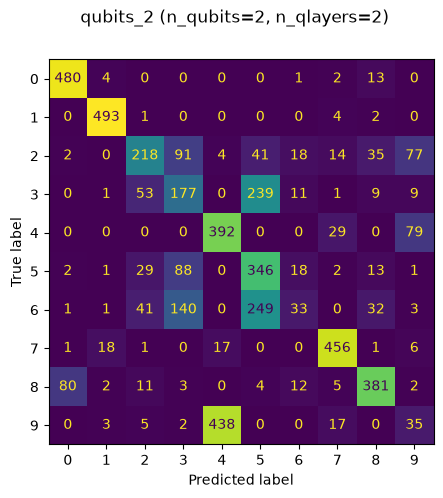

saved D:\Dissertation\qcnn-dissertation\results\ablation_full10\qubits_2\confusion_matrix.png


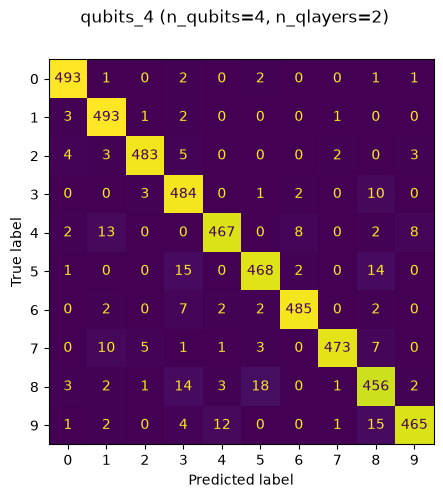

saved D:\Dissertation\qcnn-dissertation\results\ablation_full10\qubits_4\confusion_matrix.png


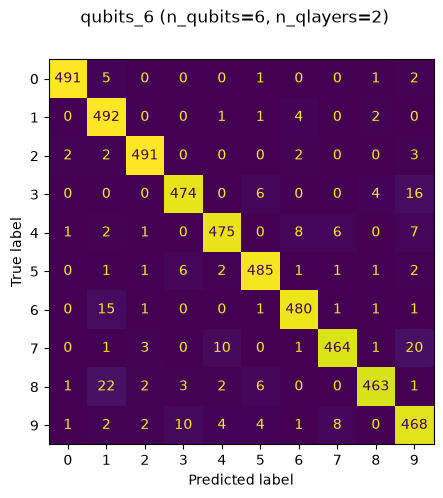

saved D:\Dissertation\qcnn-dissertation\results\ablation_full10\qubits_6\confusion_matrix.png


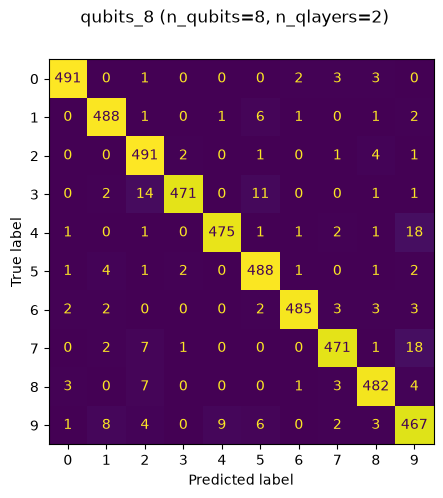

saved D:\Dissertation\qcnn-dissertation\results\ablation_full10\qubits_8\confusion_matrix.png


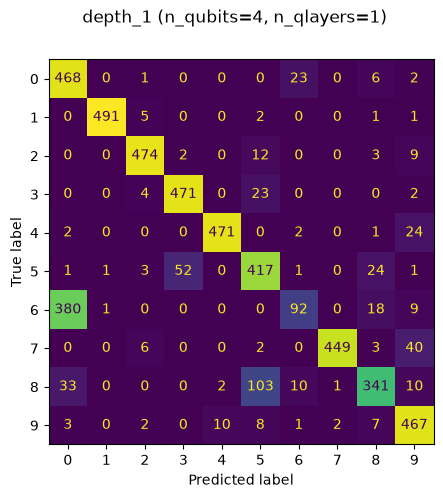

saved D:\Dissertation\qcnn-dissertation\results\ablation_full10\depth_1\confusion_matrix.png


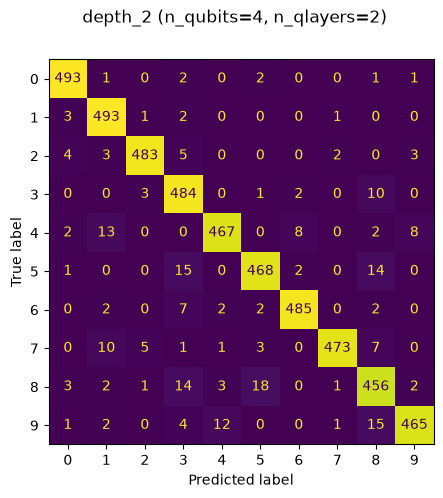

saved D:\Dissertation\qcnn-dissertation\results\ablation_full10\depth_2\confusion_matrix.png


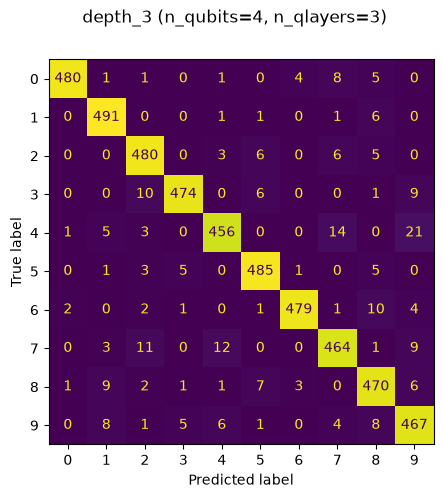

saved D:\Dissertation\qcnn-dissertation\results\ablation_full10\depth_3\confusion_matrix.png


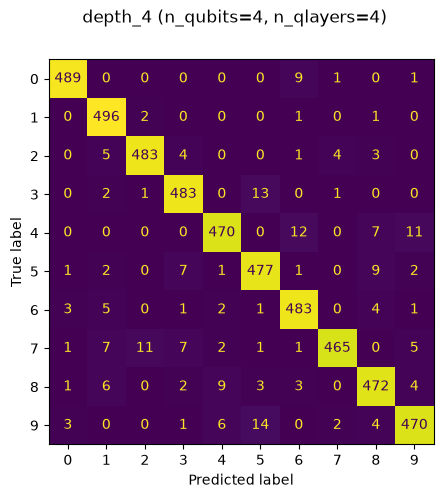

saved D:\Dissertation\qcnn-dissertation\results\ablation_full10\depth_4\confusion_matrix.png


In [13]:
criterion = nn.CrossEntropyLoss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for spec in SWEEP_A_RUNS + SWEEP_B_RUNS:
    state_path = spec['results_dir'] / 'model.pt'
    if not spec['config'].exists() or not state_path.exists():
        continue
    config = load_config(spec['config'])
    _, test_loader = get_dataloaders(config)

    model_cfg = config['model']
    model = HybridCNN(
        num_classes=model_cfg['num_classes'],
        n_qubits=model_cfg['n_qubits'],
        n_qlayers=model_cfg['n_qlayers'],
        device=model_cfg.get('device', 'default.qubit'),
    )
    model.load_state_dict(torch.load(state_path, map_location='cpu'))
    model.to(device)

    _, y_pred, y_true = evaluate(model, test_loader, criterion, device)
    fig = confusion_matrix_fig(y_true, y_pred, class_names=config['dataset']['classes'])
    fig.suptitle(f"{spec['label']} (n_qubits={model_cfg['n_qubits']}, n_qlayers={model_cfg['n_qlayers']})")
    save_path = spec['results_dir'] / 'confusion_matrix.png'
    fig.savefig(save_path, bbox_inches='tight')
    plt.show()
    print(f'saved {save_path}')

In [14]:
# Which digit pairs drive the remaining error, at the baseline configuration?
from sklearn.metrics import confusion_matrix

spec = [s for s in SWEEP_A_RUNS if s['label'] == 'qubits_4'][0]
config = load_config(spec['config'])
_, test_loader = get_dataloaders(config)
model = HybridCNN(num_classes=10, n_qubits=4, n_qlayers=2)
model.load_state_dict(torch.load(spec['results_dir'] / 'model.pt', map_location='cpu'))
model.to(device)
_, y_pred, y_true = evaluate(model, test_loader, criterion, device)

cm = confusion_matrix(y_true, y_pred)
np.fill_diagonal(cm, 0)
pairs = [(cm[i, j], i, j) for i in range(10) for j in range(10) if cm[i, j] > 0]
pairs.sort(reverse=True)
print('Top-10 confusions at n_qubits=4, n_qlayers=2 (true -> predicted, count out of 500 per class):')
for count, i, j in pairs[:10]:
    print(f'  {i} -> {j}: {count}')

Top-10 confusions at n_qubits=4, n_qlayers=2 (true -> predicted, count out of 500 per class):
  8 -> 5: 18
  9 -> 8: 15
  5 -> 3: 15
  8 -> 3: 14
  5 -> 8: 14
  4 -> 1: 13
  9 -> 4: 12
  7 -> 1: 10
  3 -> 8: 10
  4 -> 9: 8


## Interpretation notes

### The ceiling lifted, decisively

The 3-class subset compressed all seven configurations into a **2.00pp** band (97.7%-99.7%). The same
seven configurations on this regime span **35.96pp** (60.2%-96.2%) -- an **18-fold wider spread**. Section 5
restates both in test-set resolution units, which is the fair comparison since the denominators differ: the
subset's entire spread was **6 single-image steps** wide, against **1,798** here. The subset was not measuring
architecture; it was measuring quantisation noise on a task every configuration had already solved.

### Sweep A (qubits) is now cleanly monotonic -- with one large caveat

| | subset3 | full10_2500 |
|---|---|---|
| Spearman rho | 0.0 | **1.0** |
| Monotonic | no | **yes** |
| Sign changes | 2 (full zigzag) | **0** |
| Spread | 2.00pp | 35.96pp |

Experiment 3's qubit sweep had *zero* rank correlation and reversed direction twice. Here it is perfectly
rank-ordered: 60.22% -> 95.34% -> 95.66% -> 96.18%. **The zigzag did not survive the regime change**, which
means it was an artifact of the subset's ceiling, not a real property of the architecture.

But the monotonicity is carried almost entirely by one step. The 2->4 qubit jump is **+35.1pp**; the whole
4->8 range adds only **+0.84pp** (+0.32 then +0.52). The honest reading is a **saturation curve**, not a
linear return on qubits: below 4 qubits the quantum bottleneck is genuinely binding -- a 2-dimensional
latent cannot separate 10 classes -- and above it the bottleneck is no longer the limiting factor. The
sub-1pp differences across 4/6/8 qubits are single-seed measurements and should not be ranked against each
other without a multi-seed repeat.

### Sweep B (depth) still zigzags

Depth goes 82.82% -> 95.34% -> 94.92% -> 95.76%: two sign changes, Spearman 0.8, still non-monotonic. As with
qubits, one step dominates -- 1->2 layers is **+12.5pp** -- and beyond that the range 2/3/4 spans just
**0.84pp** with a dip at depth 3. So the finding splits cleanly:

- **One layer is genuinely underpowered** on a 10-class task, and the larger test set now resolves that
  clearly. Note this is the same `depth_1` that Experiment 4 found unstable across seeds on the subset;
  the two observations agree that depth 1 is the weak configuration, for what now looks like a capacity
  reason rather than a gradient one.
- **Depth beyond 2 layers does nothing measurable.** The 0.84pp residual spread across depths 2-4 is the
  same order as the 4-8 qubit residual, and at single seed it is not distinguishable from noise.

This is consistent with the Phase 6 gradient-variance result rather than in tension with it: gradient
variance showed *no* depth trend over 1-4 layers either (under one decade, non-monotonic), so neither
gradient health nor accuracy varies meaningfully with depth in this range.

### Convergence -- the main caveat on these numbers

Section 7's deltas show test loss was **still falling at epoch 15 for every configuration except depth_4**.
`qubits_4`/`depth_2` had the largest final-epoch improvement (-0.0351), meaning the shared baseline point is
the *least* converged of the set. Two consequences:

1. These are **not** fully converged models, so the absolute accuracies are lower bounds. 15 epochs was
   chosen against Section 4.4's caveat for the full run, and it is evidently still short for this regime.
2. Because configurations converge at different rates, the small (<1pp) differences above 4 qubits and above
   2 layers may partly reflect *how far along* each run is rather than its ceiling. The large effects
   (2->4 qubits, 1->2 layers) are far too big to be explained this way and are safe.

A re-run at 25-30 epochs would settle whether the 4/6/8-qubit ordering is real. That is a scope change, so
I have left it as a recommendation rather than silently altering the spec'd 15.

### Cost

**24.6 min** total wall-clock for all seven configurations, 8.2-21.8 s/epoch. That is roughly **15-37x
cheaper per epoch than `hybrid_full`** (~304 s/epoch), against a dataset only 2.4x smaller -- most of the
gain comes from using `default.qubit` instead of `lightning.qubit`, which is ~6x faster below ~15 qubits.
A 5-seed multi-seed repeat of this grid would therefore cost roughly **2 hours**, which is entirely
tractable and is the obvious next step.

### Confusion structure

With all 10 digits present the confusion matrix is finally informative. At the baseline configuration the
dominant errors are 8->5, 9->8, 5->3, 8->3 and 4->1 -- the classically hard MNIST pairs, not an artifact of
the quantum layer. The hybrid model is failing where a small classical CNN also fails.